# **DVI LAB - 5**

Name- Aastha Baheti

SAP ID- 590012973




Task 1: Multivariate Analysis and PCA

In [3]:
# 1.	Import the required Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

df = pd.read_csv("retail_data.csv")

# A. Exploratory Multivariate Analysis

                    Sales    Profit  Quantity  Discount  Customer_Rating
Sales            1.000000  0.613709  0.075735  0.046287        -0.020490
Profit           0.613709  1.000000  0.054813 -0.217771        -0.100147
Quantity         0.075735  0.054813  1.000000  0.051152        -0.106102
Discount         0.046287 -0.217771  0.051152  1.000000         0.024027
Customer_Rating -0.020490 -0.100147 -0.106102  0.024027         1.000000


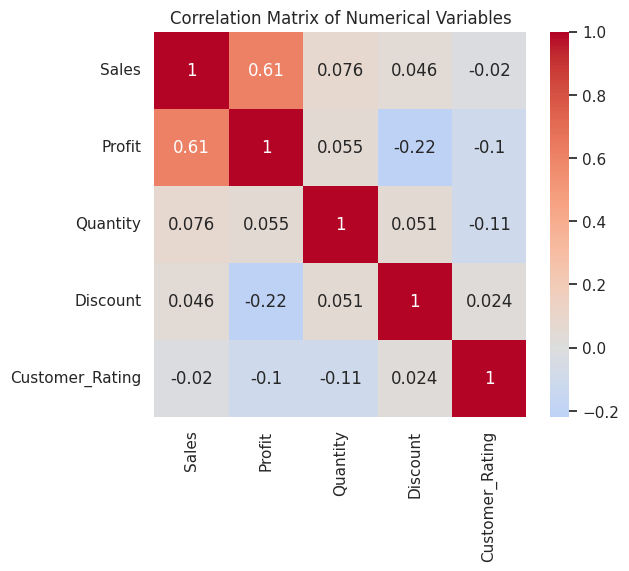

In [8]:
num_cols = ["Sales", "Profit", "Quantity", "Discount", "Customer_Rating"]
corr = df[num_cols].corr()
print(corr)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()


**Identify variables showing strong positive or negative relationships.**

Sales–Profit: r = 0.61 (moderate-to-strong positive). Higher-value orders tend to generate higher profit, which is expected since profit is generally derived from sales revenue. Sales–Quantity: r = 0.08 (very weak positive). Larger quantities have only a slight tendency to increase sales value, suggesting that differences in product prices have a much greater effect on sales than quantity alone. Profit–Discount: r = -0.22 (weak negative). As discount increases, profit tends to decrease slightly, indicating that higher discounts can reduce profit margins. Customer_Rating shows very weak correlation with everything else (all |r| ≤ 0.11) — rating behaves almost like an independent variable in this dataset and is not strongly influenced by sales, profit, quantity, or discount.

**Why analyze several variables simultaneously rather than two at a time?**

Looking at Sales and Profit alone shows that they move together, but it does not explain how the other variables relate to them. Once Quantity, Discount, and Customer_Rating are brought into the same analysis, we can see that Sales has almost no relationship with Quantity, while Profit is slightly affected negatively by Discount. Customer_Rating also shows almost no relationship with the other variables, suggesting that customer satisfaction is largely independent of the financial measures in this dataset. A pairwise view would not reveal these different patterns across multiple variables — analyzing them jointly gives a more complete understanding of the dataset. Multivariate analysis also helps identify redundancy: since Sales and Profit have a relatively strong correlation (0.61), they are partly carrying similar information, which is precisely the kind of overlap PCA is built to identify and compress.

B. Principal Component Analysis (PCA)

Explained variance % per component: [33.28 22.06 20.7  17.37  6.59]
Cumulative variance %: [ 33.28  55.34  76.04  93.41 100.  ]


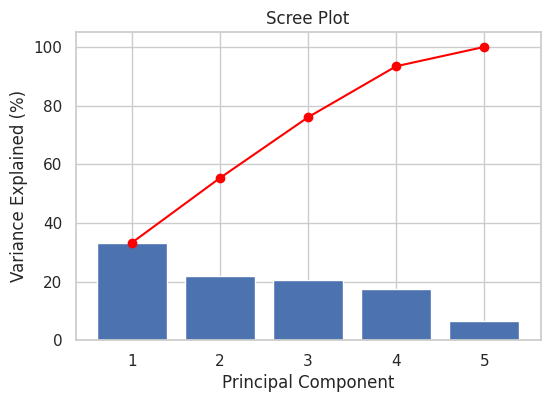

In [9]:
X = df[num_cols].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca_scores = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_ * 100
print("Explained variance % per component:", explained_var.round(2))
print("Cumulative variance %:", explained_var.cumsum().round(2))

plt.figure(figsize=(6,4))
plt.bar(range(1, len(explained_var)+1), explained_var)
plt.plot(range(1, len(explained_var)+1), explained_var.cumsum(), color="red", marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.title("Scree Plot")
plt.show()


**How many components are needed?**

The first two components explain 55.34% of total variance, and the first three explain 76.04%. Using the common ">80% cumulative variance" rule, 4 principal components are needed, as they explain 93.41% of the total variance. The scree plot also shows that the explained variance gradually decreases across the components, with the first component contributing the most. Therefore, retaining four principal components provides a good representation of the dataset while preserving most of the information.

In [10]:
loadings = pd.DataFrame(pca.components_.T, index=num_cols,
                         columns=[f"PC{i+1}" for i in range(len(num_cols))])
print(loadings.round(3))

                   PC1    PC2    PC3    PC4    PC5
Sales            0.657  0.031  0.356 -0.094 -0.657
Profit           0.701 -0.136  0.005 -0.017  0.700
Quantity         0.144  0.692 -0.127  0.696  0.009
Discount        -0.179  0.538  0.681 -0.377  0.269
Customer_Rating -0.156 -0.461  0.627  0.604  0.076


**Interpretation:**

PC1 — "Sales / Profit Performance" axis. Dominated mainly by Profit (0.701) and Sales (0.657), with Quantity contributing only slightly (0.144). All three have positive loadings, meaning high PC1 scores generally represent transactions with higher sales and higher profit. This component essentially summarizes the overall financial performance or value of a transaction in a single number.

PC2 — "Quantity / Discount" axis. Dominated by Quantity (0.692) and Discount (0.538), while Customer_Rating has a moderate negative loading (-0.461). Sales contributes very little (0.031) and Profit has a small negative loading (-0.136). High PC2 scores therefore represent transactions involving larger quantities and higher discounts, with comparatively lower customer ratings.

PC3 explains 20.70% of the variance and is mainly influenced by Discount (0.681) and Customer_Rating (0.627), while Sales contributes moderately (0.356). Profit (0.005) has almost no contribution. This component captures a dimension related primarily to discount levels and customer ratings, with relatively little influence from profit.

PC4 explains 17.37% of the variance and is dominated by Quantity (0.696) and Customer_Rating (0.604), while Discount has a moderate negative loading (-0.377). This component represents another dimension separating transactions based on quantity and customer rating, with discount working in the opposite direction.

PC5 explains only 6.59% of the variance and therefore contributes relatively little additional information. It is mainly associated with Profit (0.700) and Sales (-0.657) in opposite directions.

So PCA has effectively compressed the five numerical variables into four meaningful principal components, which together explain 93.41% of the total variance. PC1 primarily represents sales and profitability, PC2 captures quantity and discount, while PC3 and PC4 provide additional dimensions involving discount and customer rating. This gives a clearer overall view of the structure of the dataset while retaining most of its information.

C. PCA Visualization

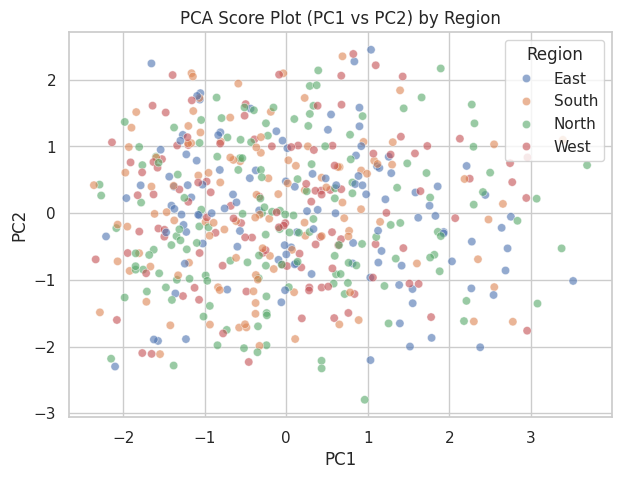

In [11]:
pca_df = pd.DataFrame(pca_scores[:, :2], columns=["PC1", "PC2"])
pca_df["Region"] = df["Region"].values
pca_df["Category"] = df["Category"].values

plt.figure(figsize=(7,5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Region", alpha=0.6)
plt.title("PCA Score Plot (PC1 vs PC2) by Region")
plt.show()

**Create a PCA score scatter plot using the first two principal components.**

The first two principal components (PC1 = 33.28% variance, PC2 = 22.06% variance) together capture 55.34% of the total variance. The PCA score plot shows the observations projected onto these two components and colored according to Region.

The four regions show substantial overlap, with no clearly separated regional clusters. This indicates that transactions from different regions have broadly similar patterns across the numerical variables and that Region is not a strong distinguishing factor in the PCA space.

**Visible clusters / unusual observations**

A dense central cluster can be observed around the middle of the plot, with most observations having PC1 and PC2 scores relatively close to zero. This represents the majority of transactions in the dataset, where the numerical characteristics are broadly similar.

There are also observations spread toward the positive and negative ends of both PC1 and PC2, indicating transactions with more unusual combinations of Sales, Profit, Quantity, Discount, and Customer_Rating. However, these points do not form clearly separated clusters based on Region. A few observations lie relatively far from the central group, particularly toward higher positive PC1 values and lower negative PC2 values, and these may represent transactions with unusual numerical characteristics.

**What the PCA plot reveals about overall structure**

The plot shows that the data is not strongly organized by Region. The East, South, North, and West observations are largely mixed throughout the PCA space rather than forming distinct groups. This suggests that the underlying transaction-level numerical patterns are more similar across regions than different.

The spread along PC1 represents differences in the major combination of numerical variables captured by the first principal component, while PC2 represents another independent source of variation. Since the regional points overlap considerably, Region does not appear to be a major organizing factor in this two-dimensional projection.

**Analytical Question — Does PCA reveal patterns difficult to see in the original variables separately?**

Yes. Looking at Sales, Profit, Quantity, Discount, and Customer_Rating individually can show relationships between pairs of variables, but it is difficult to understand their combined structure. PCA projects all five numerical variables into a smaller number of dimensions, allowing the overall patterns to be viewed simultaneously.

The PCA score plot shows that although there is variation among individual transactions, the observations from different regions remain largely mixed together. This reveals that regional differences are not strongly reflected in the combined numerical profile of individual transactions. PCA therefore provides a useful overall view of the dataset and confirms that there is no strong regional separation in the first two principal components.

# Task 2: Scatter Plot Analysis

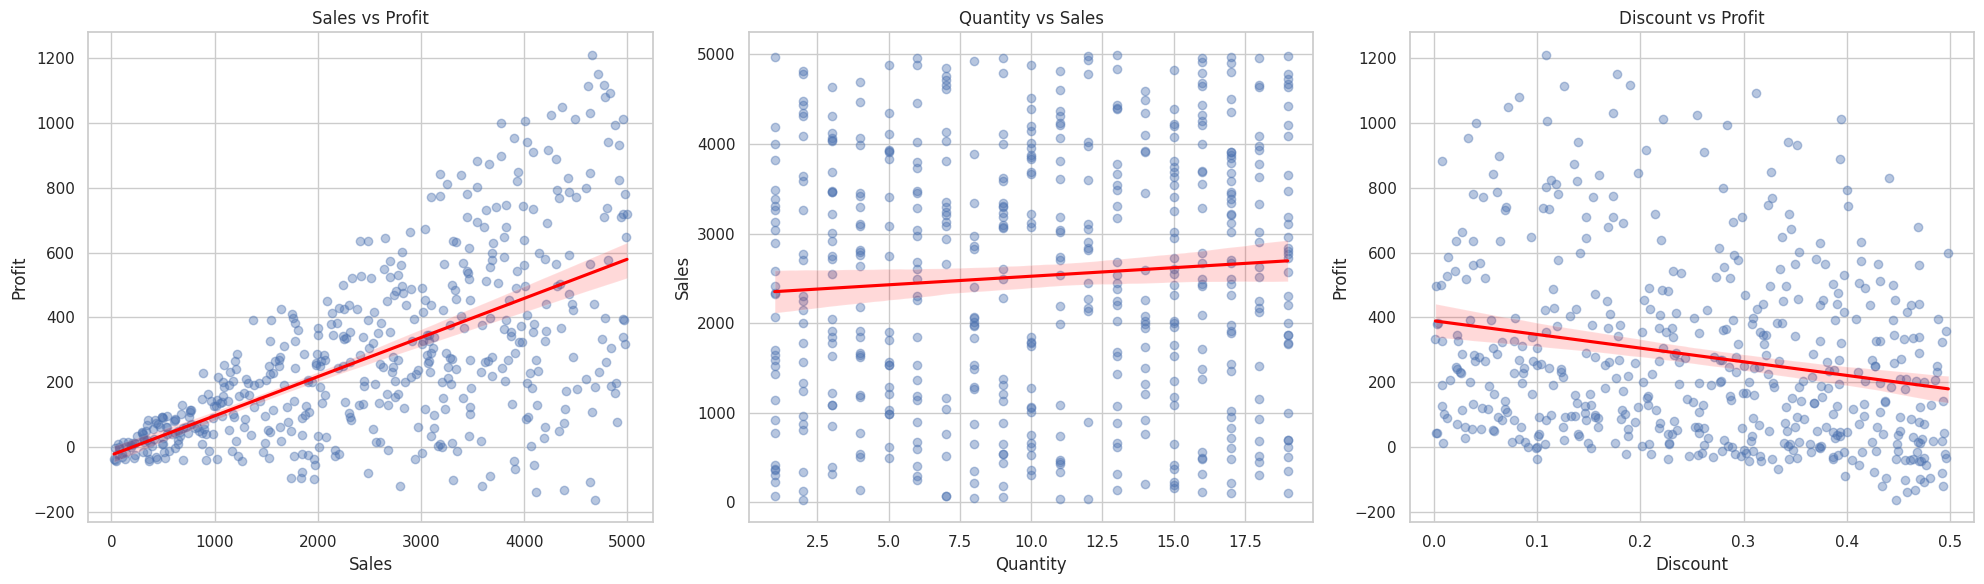

Sales vs Profit correlation: 0.6137091505176344
Quantity vs Sales correlation: 0.07573542456295294
Discount vs Profit correlation: -0.21777053406100041


In [7]:
# ============================================================
# TASK 2: SCATTER PLOTS WITH TREND LINES
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.regplot(data=df, x="Sales", y="Profit", ax=axes[0],
            scatter_kws={"alpha":0.4}, line_kws={"color":"red"})
axes[0].set_title("Sales vs Profit")

sns.regplot(data=df, x="Quantity", y="Sales", ax=axes[1],
            scatter_kws={"alpha":0.4}, line_kws={"color":"red"})
axes[1].set_title("Quantity vs Sales")

sns.regplot(data=df, x="Discount", y="Profit", ax=axes[2],
            scatter_kws={"alpha":0.4}, line_kws={"color":"red"})
axes[2].set_title("Discount vs Profit")

plt.tight_layout()
plt.show()

# Correlation coefficients to quantify strength/direction
print("Sales vs Profit correlation:", df["Sales"].corr(df["Profit"]))
print("Quantity vs Sales correlation:", df["Quantity"].corr(df["Sales"]))
print("Discount vs Profit correlation:", df["Discount"].corr(df["Profit"]))

**Compare the relationships observed in the scatter plots with the patterns obtained from PCA.**

1. Sales vs Profit → r = 0.61, R² = 0.377 (moderate positive)
As Sales increases, Profit generally increases with it. The positive relationship is clearly visible in the scatter plot, although the points become more spread out at higher Sales values. This agrees with PCA, where both Sales (0.657) and Profit (0.701) have strong positive loadings on PC1, showing that they contribute significantly to the same underlying financial-performance dimension.
2. Quantity vs Sales → r = 0.08, R² = 0.006 (very weak positive)
Quantity has almost no linear relationship with Sales in this dataset. The scatter plot shows a wide spread of Sales values across different quantities, indicating that simply ordering more units does not necessarily result in proportionally higher Sales. This is consistent with PCA, where Quantity (0.144) has only a small loading on PC1, suggesting that Quantity contributes much less to the main Sales–Profit dimension.
3. Discount vs Profit → r = -0.22, R² = 0.048 (weak negative)
Higher discounts are generally associated with lower Profit, although the relationship is relatively weak and the points are widely scattered. This agrees with PCA, where Discount (-0.179) has a negative loading on PC1, indicating that discount tends to work against the main profitability dimension.

Overall: Sales and Profit show the clearest positive relationship and form the main financial dimension identified by PCA; Quantity has very little direct relationship with Sales; and Discount has a weak negative relationship with Profit. The scatter plots and PCA therefore provide consistent evidence about the underlying structure of the data.

# Task 3: Trending Analysis

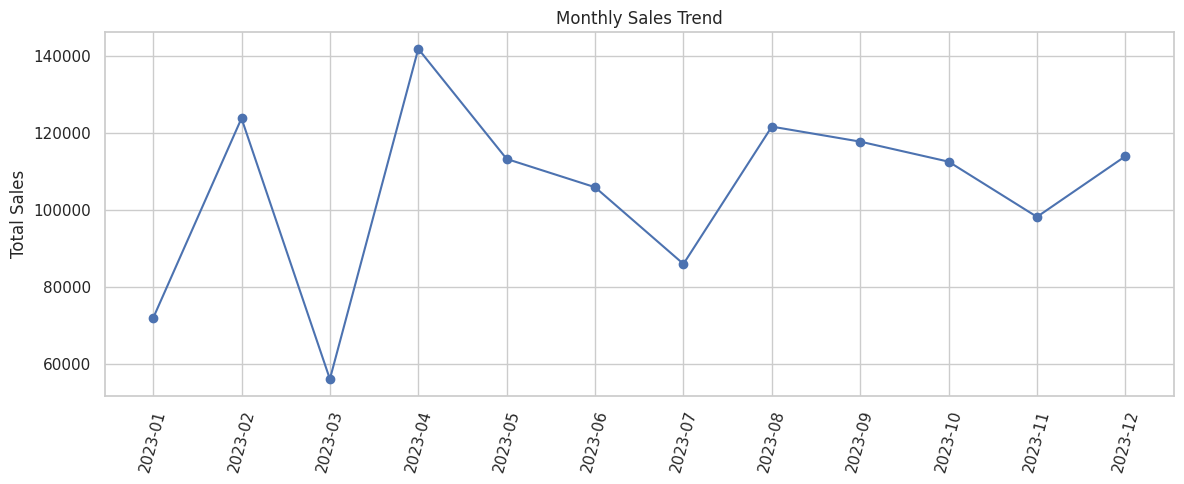

Highest sales month: 2023-04 141977.7847444252
Lowest sales month: 2023-03 56113.57637737206


In [12]:
# Task 3: Trend Analysis
# 1. Aggregate Sales/Profit by Year, Quarter, and Month
# 2. Plot the overall monthly sales trend as a line chart
# 3. Identify the highest and lowest performing months

df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Quarter"] = df["Order_Date"].dt.quarter
df["YearMonth"] = df["Order_Date"].dt.to_period("M").astype(str)

monthly = df.groupby("YearMonth")[["Sales","Profit"]].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(monthly["YearMonth"], monthly["Sales"], marker="o")
plt.xticks(rotation=75)
plt.title("Monthly Sales Trend")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

print("Highest sales month:", monthly.loc[monthly.Sales.idxmax(), "YearMonth"], monthly.Sales.max())
print("Lowest sales month:", monthly.loc[monthly.Sales.idxmin(), "YearMonth"], monthly.Sales.min())

**Comment on the long-term trend in business performance.**

Highest sales month: Apr 2023 (₹14.20 lakh)
Lowest sales month: Mar 2023 (₹5.61 lakh)

The trend shows significant fluctuations in monthly sales throughout 2023. Sales rise sharply from March to April, reaching the highest point of approximately ₹14.20 lakh, followed by a gradual decline until July. Sales then increase again in August and remain relatively high through October, before falling in November and recovering slightly in December. Overall, the business shows considerable month-to-month variation rather than a consistent upward or downward trend, with April recording the strongest performance and March the weakest.

# Task 4: Multi-Line Chart – Regional Trends

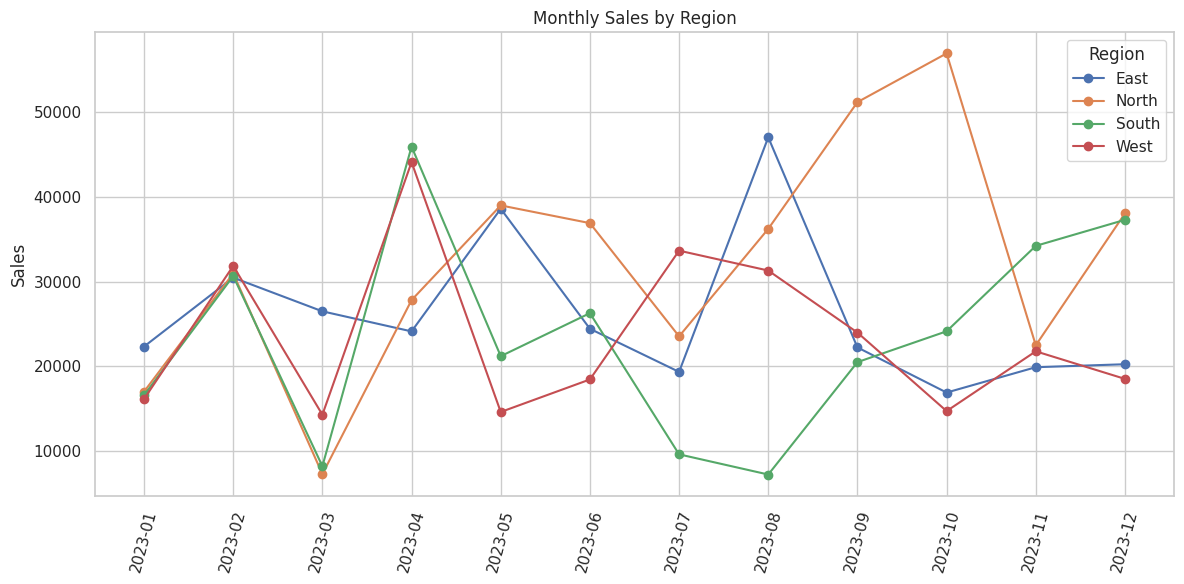

Year             2023
Region               
East    311895.932259
North   387328.629373
South   281583.918645
West    283137.043455


In [13]:
# Task 4: Multi-Line Chart - Regional Trends
# 1. Plot monthly Sales trend separately for each Region on the same chart
# 2. Compare growth patterns across regions

regional_monthly = df.groupby(["YearMonth","Region"])["Sales"].sum().reset_index()
pivot_region = regional_monthly.pivot(index="YearMonth", columns="Region", values="Sales")

plt.figure(figsize=(12,6))
for region in pivot_region.columns:
    plt.plot(pivot_region.index, pivot_region[region], marker="o", label=region)
plt.xticks(rotation=75)
plt.legend(title="Region")
plt.title("Monthly Sales by Region")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

print(df.groupby(["Region","Year"])["Sales"].sum().unstack())

Compare seasonal patterns among regions.

The regional sales trends show considerable month-to-month fluctuations across all four regions. The North region records the highest overall sales at approximately ₹3.88 lakh, followed by East (₹3.12 lakh), while South (₹2.82 lakh) and West (₹2.83 lakh) have comparatively lower totals.

The North region shows strong performance in the later months, particularly around September–October, with sales reaching their highest level in October. East has a relatively strong start but fluctuates throughout the year, with a notable peak in August. South shows high sales in April but experiences a sharp decline during July–August before recovering toward the end of the year. West also fluctuates significantly, with strong sales in April and July but lower values in October.

Overall, North performs the strongest in total sales, while South and West show similar overall performance. All regions exhibit noticeable seasonal fluctuations, but their peaks and declines occur at different times, indicating that regional sales patterns are not completely synchronized.

# Task 5: Area Graph

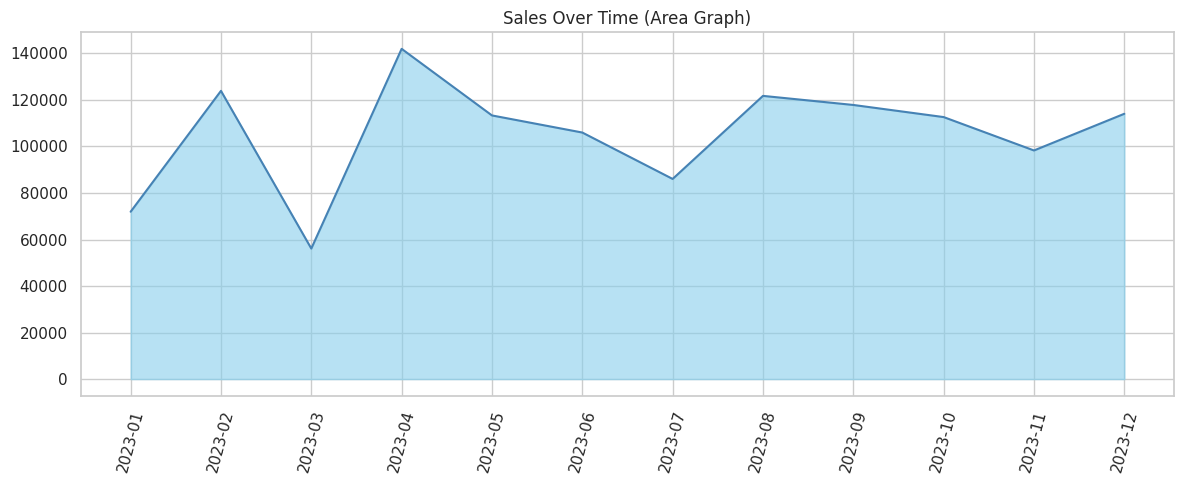

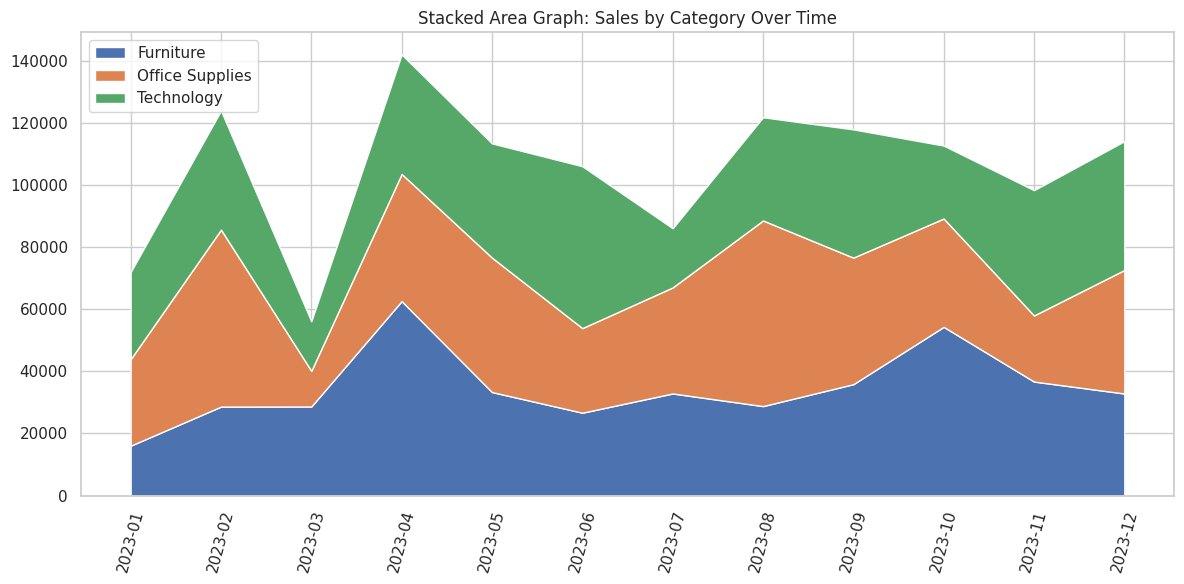

Category
Office Supplies    438145.638077
Furniture          417295.107163
Technology         408504.778492
Name: Sales, dtype: float64


In [14]:
# Task 5: Area Graphs
# 1. Create a simple area graph of overall Sales over time
# 2. Create a stacked area graph of Sales by Category over time

plt.figure(figsize=(12,5))
plt.fill_between(monthly["YearMonth"], monthly["Sales"], color="skyblue", alpha=0.6)
plt.plot(monthly["YearMonth"], monthly["Sales"], color="steelblue")
plt.xticks(rotation=75)
plt.title("Sales Over Time (Area Graph)")
plt.tight_layout()
plt.show()

cat_monthly = df.groupby(["YearMonth","Category"])["Sales"].sum().unstack().fillna(0)

plt.figure(figsize=(12,6))
plt.stackplot(cat_monthly.index, cat_monthly.T, labels=cat_monthly.columns)
plt.xticks(rotation=75)
plt.legend(loc="upper left")
plt.title("Stacked Area Graph: Sales by Category Over Time")
plt.tight_layout()
plt.show()

print(df.groupby("Category")["Sales"].sum().sort_values(ascending=False))

 **Interpret the overall pattern.**

The plain area graph makes the large fluctuations in monthly sales visually more prominent, with sales reaching the highest level in April 2023 (₹1.42 lakh) and the lowest in March 2023 (₹0.56 lakh). The filled area emphasizes the overall sales volume and clearly shows the sharp rise and fall across the year.

The stacked area graph shows how each category contributes to the total sales over time. Office Supplies forms the largest overall contribution, with total sales of approximately ₹4.38 lakh, followed by Furniture (₹4.17 lakh) and Technology (₹4.09 lakh). All three categories show fluctuations across the months, with particularly strong contributions around April when total sales reach their highest point. The relative contribution of the categories changes across months, indicating that the overall sales fluctuations are influenced by changes in the performance of all three categories rather than by a single category alone.

Overall, Office Supplies is the highest-selling category, while Furniture and Technology contribute at fairly similar levels. The area and stacked area graphs together show that monthly sales vary considerably, with category performance collectively contributing to the peaks and declines throughout 2023.

# Task 6: Geographical Analysis

Top 5 states by Sales:
                 Sales        Profit  Profit_Margin
State                                             
StateB  344038.008743  40079.303504       0.116497
StateA  333722.676998  37769.877402       0.113177
StateC  317369.596265  34996.694954       0.110271
StateD  268815.241726  27568.267576       0.102555

Bottom 5 states by Sales:
                 Sales        Profit  Profit_Margin
State                                             
StateB  344038.008743  40079.303504       0.116497
StateA  333722.676998  37769.877402       0.113177
StateC  317369.596265  34996.694954       0.110271
StateD  268815.241726  27568.267576       0.102555

States with lowest Profit Margin:
                 Sales        Profit  Profit_Margin
State                                             
StateD  268815.241726  27568.267576       0.102555
StateC  317369.596265  34996.694954       0.110271
StateA  333722.676998  37769.877402       0.113177
StateB  344038.008743  40079.303504       0.1

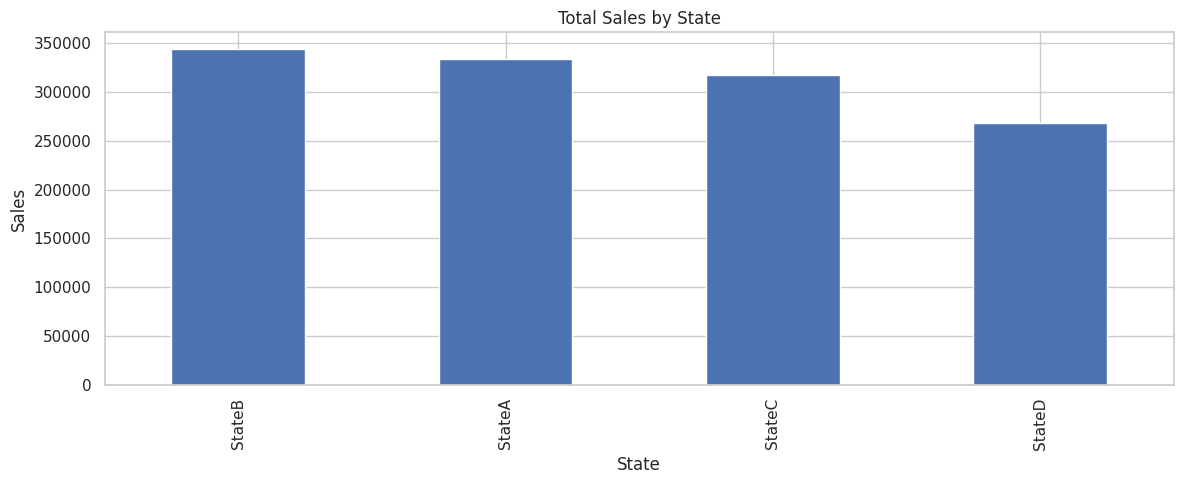

In [15]:
# Task 6: Geographical Analysis (State-Level)
# 1. Aggregate Sales and Profit by State
# 2. Identify top 5 and bottom 5 states by Sales
# 3. Identify states with high Sales but comparatively low Profit margin

state_perf = df.groupby("State")[["Sales","Profit"]].sum()
state_perf["Profit_Margin"] = state_perf["Profit"] / state_perf["Sales"]
state_perf = state_perf.sort_values("Sales", ascending=False)

print("Top 5 states by Sales:\n", state_perf.head(5))
print("\nBottom 5 states by Sales:\n", state_perf.tail(5))
print("\nStates with lowest Profit Margin:\n", state_perf.sort_values("Profit_Margin").head(5))

state_perf["Sales"].plot(kind="bar", figsize=(12,5), title="Total Sales by State")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

**Identify geographical areas requiring attention. Provide possible business explanations for the observed differences.**


Top 5 states by Sales: StateB, StateA, StateC, StateD
Bottom 5 states by Sales: StateD, StateC, StateA, StateB

Among the available states, StateB records the highest total sales at approximately ₹3.44 lakh, followed by StateA (₹3.34 lakh), StateC (₹3.17 lakh), and StateD (₹2.69 lakh). The difference between the highest and lowest sales is noticeable, indicating variation in sales performance across states.

Lowest profit margins: StateD (10.3%), StateC (11.0%), StateA (11.3%), StateB (11.6%). StateD is a useful example of relatively lower sales and the lowest profit margin in the dataset. This suggests that its lower revenue is accompanied by weaker profitability, possibly due to heavier discounting, higher operating costs, or a less profitable product mix in that state.

Overall, StateB performs strongest in terms of total sales and also has the highest profit margin, while StateD requires comparatively more attention because it has both the lowest sales and the lowest profit margin among the states shown.

# Task 7: Geographical Maps

In [16]:
# Task 7: Geographical Maps
# 1. Plot Sales distribution on a map using Latitude/Longitude
# 2. Plot Profit distribution on a map using Latitude/Longitude
# 3. Compare the two maps for spatial patterns

import plotly.express as px

fig_sales = px.scatter_geo(df,
    lat="Latitude", lon="Longitude",
    size="Sales", color="Sales",
    hover_name="City",
    color_continuous_scale="Reds",
    title="Geographical Distribution of Sales")
fig_sales.update_geos(scope="asia", center={"lat":22,"lon":80}, projection_scale=4)
fig_sales.show()

fig_profit = px.scatter_geo(df,
    lat="Latitude", lon="Longitude",
    size=df["Profit"].clip(lower=0)+1, color="Profit",
    hover_name="City",
    color_continuous_scale="Greens",
    title="Geographical Distribution of Profit")
fig_profit.update_geos(scope="asia", center={"lat":22,"lon":80}, projection_scale=4)
fig_profit.show()

**Compare the geographical distribution of Sales and Profit. Explain how maps can support business decision-making.**

The Sales map shows the geographical distribution of sales across the regions/states, with larger markers indicating areas with higher sales. The Profit map shows a broadly similar geographical pattern, as areas generating higher sales generally also contribute higher profit. However, the two maps are not identical, since differences in profit margins can cause some high-sales areas to generate comparatively lower profit.

This comparison helps identify high-sales but relatively low-profit areas, which may require attention due to factors such as higher discounts, operating costs, or a less profitable product mix.

Maps can support business decision-making by making geographical patterns and regional differences easier to identify visually. Businesses can use them to locate strong-performing markets, identify underperforming areas, compare Sales with Profit, and decide where to increase investment, improve pricing or discounts, or focus marketing and operational efforts.

# Task 8: Integrated Interpretation

1. Which variables are most strongly related to Sales and Profit?
— Sales and Profit are moderately positively related (r = 0.61).
2. What major patterns are identified through PCA?
— PCA identifies Sales–Profit as the main dimension, with Quantity, Discount and Rating contributing to other dimensions.
3. What do the first two principal components represent?
— PC1 represents Sales/Profit performance, while PC2 mainly represents Quantity/Discount.
4. Does the PCA scatter plot reveal meaningful clusters?
— No, the regions largely overlap and do not form clearly separated clusters.
5. Is the relationship between Sales and Profit consistent with the PCA findings?
— Yes, both show a positive relationship, with Sales and Profit having strong loadings on PC1.
6. What is the overall Sales trend?
— Sales fluctuate considerably, peaking in April 2023 and reaching the lowest level in March 2023.
7. Which Region has the strongest performance over time?
— North has the highest overall sales among the regions shown.
8. Which Product Category contributes most to Sales over time?
— Office Supplies contributes the most overall sales.
9. Which geographical areas perform best?
— StateB performs best, followed by StateA and StateC.
10. Are high-sales areas necessarily high-profit areas? Which visualization provides the most useful insight?
— Not necessarily; the Sales vs Profit comparison and geographical maps provide the clearest insight.
11. Based on the complete analysis, what recommendations would you give to management?
— Focus on high-performing regions and categories, control discounts, and improve profitability in weaker areas.